# Multi-GPU · single-process shot parallelism

When you have several GPUs on **one machine** the cheapest way to use them with SWEEP is to keep one Python interpreter and dispatch different shots to different cards yourself. This sidesteps the launch / IPC complexity of `torchrun` (covered in the DDP doc) and the API is just "a list of `PropTorch` instances, one per device".

The pattern:

1. build *N* `PropTorch` instances, one per `cuda:i`
2. replicate the velocity tensor on each device with `requires_grad=True`
3. slice the shot index list into *N* groups; rank *i* runs forward + backward on its own slice
4. all-reduce the gradients onto `cuda:0`, take one Adam step, then broadcast the updated `vp` back to every device

This notebook demos the pattern on a tiny two-layer model so the bookkeeping is visible. If your machine only has one GPU the multi-GPU cell falls back to a single-device run (same code, just `[cuda:0]`).

## 1. Setup

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

ngpu = torch.cuda.device_count()
devices = [torch.device(f'cuda:{i}') for i in range(ngpu)] if ngpu else [torch.device('cpu')]
print(f'visible CUDA devices: {ngpu}')
print('using devices:', devices)
if ngpu < 2:
    print('NOTE: this host only exposes one accelerator; the multi-device cell below still runs, but with a single solver — so wall time is identical to the baseline. The point of the cell is the *code pattern*, not the speedup.')

visible CUDA devices: 1
using devices: [device(type='cuda', index=0)]
NOTE: this host only exposes one accelerator; the multi-device cell below still runs, but with a single solver — so wall time is identical to the baseline. The point of the cell is the *code pattern*, not the speedup.


## 2. Two-layer model, shot grid, wavelet

In [2]:
shape = (96, 128)
dh, dt, nt = 10.0, 2e-3, 600
freq, delay = 10.0, 0.12

vp_true_np = np.full(shape, 1500.0, dtype=np.float32)
vp_true_np[shape[0] // 2:, :] = 2500.0
vp_init_np = np.full(shape, 1500.0, dtype=np.float32)

# 8 shots evenly spread along the surface, single receiver line
nshots = 8
src_x = np.linspace(8, shape[1] - 9, nshots, dtype=np.int64)
sources = np.stack([src_x, np.full(nshots, 2, dtype=np.int64)], axis=1)
rec_x = np.linspace(0, shape[1] - 1, 64, dtype=np.int64)
one_shot_rec = np.stack([rec_x, np.full_like(rec_x, 4)], axis=1)
receivers = np.broadcast_to(one_shot_rec, (nshots, *one_shot_rec.shape)).copy()

t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq).astype(np.float32)
print(f'{nshots} shots, {len(rec_x)} receivers/shot')

8 shots, 64 receivers/shot


## 3. Helper — build one solver per device

In [3]:
def build_solver(dev):
    return PropTorch(
        Acoustic(device=dev), shape=shape, dh=dh, dt=dt, dev=dev,
        use_ckpt=False, impl='eager',
    )

solvers = [build_solver(d) for d in devices]
print(f'built {len(solvers)} solvers')

built 1 solvers


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [4]:
from sweep.equations import Acoustic
eq = Acoustic(device=devices[0])
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


## 4. Observed data — single device is enough

We only need one forward pass per shot to record the true-model gather; do it on `devices[0]`.

In [5]:
with torch.no_grad():
    obs_full = solvers[0](
        wavelet, sources, receivers,
        models=[torch.tensor(vp_true_np, device=devices[0])],
    ).detach().cpu()
print('obs shape (nshots, nt, nrec, nfields):', tuple(obs_full.shape))

obs shape (nshots, nt, nrec, nfields): (8, 600, 64, 1)


## 5. Baseline — single GPU, all shots in one process

One step of FWI: forward + L2 misfit + backward over all 8 shots on one device. We time this so we have a baseline to compare against.

In [6]:
# Warm CUDA / cudnn so the first cell doesn't pay init / autotune costs.
with torch.no_grad():
    _ = solvers[0](wavelet, sources[:1], receivers[:1],
                   models=[torch.tensor(vp_init_np, device=devices[0])])
if devices[0].type == 'cuda':
    torch.cuda.synchronize()

t0 = time.perf_counter()
vp_t = torch.tensor(vp_init_np, device=devices[0], requires_grad=True)
total_loss = 0.0
for s in range(nshots):
    syn = solvers[0](wavelet, sources[s:s+1], receivers[s:s+1], models=[vp_t])
    loss = 0.5 * (syn - obs_full[s:s+1].to(devices[0])).pow(2).sum()
    loss.backward()
    total_loss += float(loss.detach())
if devices[0].type == 'cuda':
    torch.cuda.synchronize()
elapsed_single = time.perf_counter() - t0
single_grad = vp_t.grad.detach().clone()
print(f'single-device: loss={total_loss:.4e}  elapsed={elapsed_single:.3f} s')

single-device: loss=9.4951e+01  elapsed=7.828 s


## 6. Multi-device — shots split across `devices`

Same FWI step, but each shot is dispatched to its assigned GPU. The gradient is reduced back onto `devices[0]` after every device has finished its slice.

In [7]:
def split_shots(nshots, ndev):
    # contiguous slicing — each device owns nshots // ndev consecutive shots,
    # the first (nshots % ndev) devices take one extra to soak up the remainder
    return [list(chunk) for chunk in np.array_split(np.arange(nshots), ndev)]

shot_groups = split_shots(nshots, len(devices))
for d, group in zip(devices, shot_groups):
    print(f'  {d}: shots {group}')

# replicate vp_init on every device — each replica gets its own grad
vp_replicas = [torch.tensor(vp_init_np, device=d, requires_grad=True) for d in devices]

if devices[0].type == 'cuda':
    torch.cuda.synchronize()
t0 = time.perf_counter()

device_losses = [0.0] * len(devices)
for di, (dev, group, solver_d, vp_d) in enumerate(zip(devices, shot_groups, solvers, vp_replicas)):
    if not group:
        continue
    for s in group:
        syn = solver_d(wavelet, sources[s:s+1], receivers[s:s+1], models=[vp_d])
        loss = 0.5 * (syn - obs_full[s:s+1].to(dev)).pow(2).sum()
        loss.backward()
        device_losses[di] += float(loss.detach())

# all-reduce the gradient onto devices[0] — manual sum since this is single-process
summed_grad = torch.zeros_like(vp_replicas[0])
for vp_d in vp_replicas:
    summed_grad += vp_d.grad.to(devices[0])

if devices[0].type == 'cuda':
    torch.cuda.synchronize()
elapsed_multi = time.perf_counter() - t0
multi_loss = sum(device_losses)
print(f'multi-device: loss={multi_loss:.4e}  elapsed={elapsed_multi:.3f} s  (ngpu={len(devices)})')

  cuda:0: shots [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


multi-device: loss=9.4951e+01  elapsed=6.750 s  (ngpu=1)


## 7. Sanity check — gradients should match

The same global loss → same global gradient, no matter how shots were dispatched. We compare the single-device gradient with the summed multi-device gradient.

||single - multi||  / ||single||  =  0.000e+00
wall-clock speedup: 1.16x  on 1 device(s)


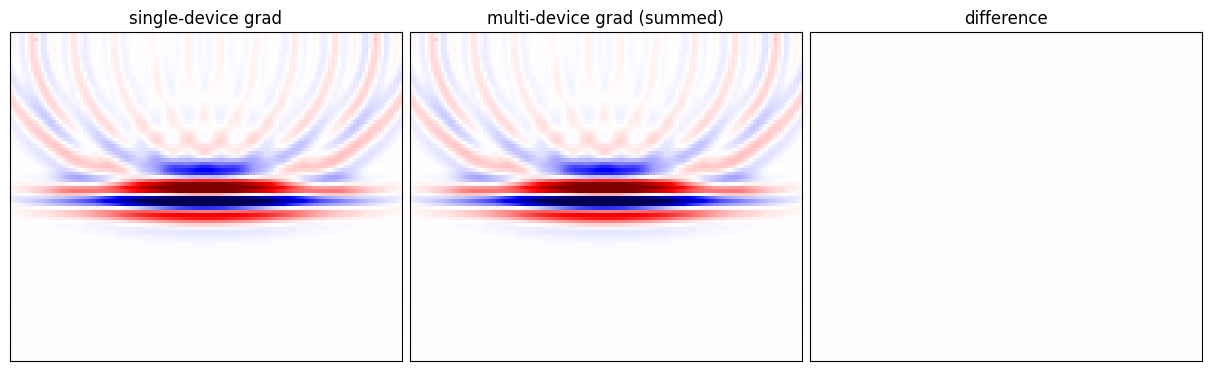

In [8]:
rel_err = torch.linalg.norm(single_grad - summed_grad) / torch.linalg.norm(single_grad)
print(f'||single - multi||  / ||single||  =  {float(rel_err):.3e}')

speedup = elapsed_single / elapsed_multi if elapsed_multi > 0 else float('nan')
print(f'wall-clock speedup: {speedup:.2f}x  on {len(devices)} device(s)')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for ax, g, name in zip(
        axes,
        [single_grad.cpu().numpy(), summed_grad.cpu().numpy(),
         (single_grad - summed_grad).cpu().numpy()],
        ['single-device grad', 'multi-device grad (summed)', 'difference']):
    vmax = np.percentile(np.abs(g), 99.0) + 1e-30
    ax.imshow(g, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 8. Plugging into an Adam loop

To turn this into FWI you'd wrap the multi-device step in a loop, broadcast the updated `vp_replicas[0]` back to every device after `optimizer.step()`, and zero every replica's grad at the start of the next iteration:

```python
opt = torch.optim.Adam([vp_replicas[0]], lr=25.0)
for epoch in range(n_iter):
    for vp_d in vp_replicas:
        vp_d.grad = None
    # ... (same dispatch + sum loop as above; gradient lands on vp_replicas[0]) ...
    opt.step()
    with torch.no_grad():
        for vp_d in vp_replicas[1:]:
            vp_d.copy_(vp_replicas[0])
```

For larger jobs (many shots, big models) the multi-process DDP version in [`Multi-GPU DDP`](../../examples/multi_gpu_dist/) scales further because each rank gets a fresh CUDA context.

---

**Download this notebook** &mdash; [`12_multi_gpu_single_process.ipynb`](https://github.com/DeepWave-KAUST/sweep/raw/main/examples/notebooks/12_multi_gpu_single_process/)
&middot; or [browse on GitHub](https://github.com/DeepWave-KAUST/sweep/blob/main/examples/notebooks/12_multi_gpu_single_process/)